# Battery data inspection / 데이터 구조 탐색

셀 메타데이터와 summary를 먼저 확인합니다. 원본을 필터링하거나 수정하지 않습니다.
공통 로더는 세 Batch에서 검증하며, 아래 `BATCH_NAME`을 바꿔 상세 탐색합니다.

실행 방법: 프로젝트 `.venv` 커널을 선택하고 위에서부터 전체 실행합니다.
상세 cycle 곡선은 명시적인 **저장 인덱스**로 일부만 읽습니다. cycle 10·100과의 대응은 후속 검증 대상입니다.

In [1]:
from pathlib import Path
import sys
import importlib

cwd = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in [cwd, *cwd.parents]
                     if (p / "src/load_data.py").is_file()
                     and (p / "requirements.txt").is_file()), None)
if PROJECT_ROOT is None:
    raise RuntimeError("프로젝트 디렉토리에서 노트북을 실행하세요.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from src import load_data
importlib.reload(load_data)

print("Python:", sys.executable)
print("Project:", PROJECT_ROOT)
BATCH_NAME = "batch1"
DATA_DIR = PROJECT_ROOT / "data/raw"
plt.rcParams.update({"figure.figsize": (10, 4), "font.size": 11})

Matplotlib is building the font cache; this may take a moment.


Python: /Users/soobin/myfolder/workspace/mini-project-data-analysis/.venv/bin/python
Project: /Users/soobin/myfolder/workspace/mini-project-data-analysis


## 1. 원본 파일과 실행 조건

In [2]:
file_inventory = pd.DataFrame([
    {"batch": name, "filename": filename,
     "exists": (DATA_DIR / filename).is_file(),
     "size_GiB": (DATA_DIR / filename).stat().st_size / 1024**3
                 if (DATA_DIR / filename).exists() else np.nan}
    for name, filename in load_data.BATCH_FILES.items()
])
display(file_inventory)
path = load_data.batch_path(BATCH_NAME, DATA_DIR)
cells, summary, quality = load_data.load_batch(path, BATCH_NAME)
print(f"Selected: {BATCH_NAME}; {len(cells)} cells; {len(summary):,} summary rows")

,batch,filename,exists,size_GiB
0,batch1,2017-05-12_batchdata_updated_struct_errorcorre...,True,2.817549
1,batch2,2018-02-20_batchdata_updated_struct_errorcorre...,True,1.883692
2,batch3,2018-04-12_batchdata_updated_struct_errorcorre...,True,3.014403


Selected: batch1; 46 cells; 38,811 summary rows


## 2. 셀 정보와 summary

`cell_id`는 파일 내부 0부터 시작하는 위치입니다. 물리 셀 식별자는 아닙니다.
`barcode_raw`, `channel_id_raw`는 원본 숫자 표현을 보존하며 동일 셀 판정에 바로 사용하지 않습니다.
cycle 번호는 원본 `summary.cycle`을 그대로 유지합니다.

In [3]:
display(cells.head())
display(summary.head(12))
display(cells["cycle_life"].describe().to_frame())
display(cells.groupby("charging_policy")["cycle_life"].agg(["count", "mean", "min", "max"]))

,batch,cell_id,cycle_life,charging_policy,policy_raw,barcode_raw,channel_id_raw,summary_rows
0,batch1,0,1190.0,3.6C(80%)-3.6C,3_6C-80PER_3_6C,"(3707764736, 2, 1, 1, 1, 1)","(3707764736, 2, 1, 1, 47, 1)",1189
1,batch1,1,1179.0,3.6C(80%)-3.6C,3_6C-80PER_3_6C,"(3707764736, 2, 1, 1, 2, 1)","(3707764736, 2, 1, 1, 48, 1)",1178
2,batch1,2,1177.0,3.6C(80%)-3.6C,3_6C-80PER_3_6C,"(3707764736, 2, 1, 1, 3, 1)","(3707764736, 2, 1, 1, 49, 1)",1176
3,batch1,3,1226.0,4C(80%)-4C,4C-80PER_4C,"(3707764736, 2, 1, 1, 4, 1)","(3707764736, 2, 1, 1, 50, 1)",1225
4,batch1,4,1227.0,4C(80%)-4C,4C-80PER_4C,"(3707764736, 2, 1, 1, 5, 1)","(3707764736, 2, 1, 1, 51, 1)",1226


,batch,cell_id,cycle,QD,QC,IR,Tavg,Tmax,Tmin,chargetime,cycle_life,charging_policy
0,batch1,0,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1190.0,3.6C(80%)-3.6C
1,batch1,0,2.0,1.070689,1.071042,0.016742,31.875011,35.652016,29.566130,13.341250,1190.0,3.6C(80%)-3.6C
2,batch1,0,3.0,1.071900,1.071674,0.016724,31.931490,35.692978,29.604385,13.425777,1190.0,3.6C(80%)-3.6C
3,batch1,0,4.0,1.072510,1.072304,0.016681,31.932603,35.680588,29.744202,13.425167,1190.0,3.6C(80%)-3.6C
4,batch1,0,5.0,1.073174,1.072970,0.016662,31.959322,35.728691,29.644709,13.341442,1190.0,3.6C(80%)-3.6C
5,batch1,0,6.0,1.073576,1.073491,0.016623,31.961062,35.711758,29.752932,13.340835,1190.0,3.6C(80%)-3.6C
6,batch1,0,7.0,1.073992,1.073922,0.016600,31.900562,35.615650,29.564377,13.340198,1190.0,3.6C(80%)-3.6C
7,batch1,0,8.0,1.074374,1.074158,0.016577,31.921668,35.546783,29.628630,13.425442,1190.0,3.6C(80%)-3.6C
8,batch1,0,9.0,1.074492,1.074337,0.016588,31.870082,35.539406,29.597345,13.425190,1190.0,3.6C(80%)-3.6C
9,batch1,0,10.0,1.074537,1.074353,0.016572,31.841053,35.499729,29.687315,13.425633,1190.0,3.6C(80%)-3.6C


,cycle_life
count,46.000000
mean,844.717391
std,184.629198
min,534.000000
25%,703.250000
50%,858.500000
75%,914.250000
max,1227.000000


,count,mean,min,max
charging_policy,,,,
3.6C(80%)-3.6C,3,1182.0,1177.0,1190.0
4.4C(80%)-4.4C,1,1074.0,1074.0,1074.0
4.8C(80%)-4.8C,2,753.0,636.0,870.0
4C(80%)-4C,2,1226.5,1226.0,1227.0
5.4C(40%)-3.6C,2,966.5,879.0,1054.0
5.4C(50%)-3.6C,2,899.5,897.0,902.0
5.4C(50%)-3C,2,847.0,788.0,906.0
5.4C(60%)-3.6C,2,859.5,857.0,862.0
5.4C(60%)-3C,2,799.5,719.0,880.0


## 3. 데이터 품질

NaN/무한값과 0값을 별도로 셉니다. 0은 결측으로 자동 치환하지 않습니다.
summary 필드 길이가 다르면 로더가 오류를 내며, 상세 cycle 필드 길이와의 일치 여부도 기록합니다.

In [4]:
display(quality.head())
display(quality.filter(regex="_(nonfinite|zero)$").sum().to_frame("count"))
checks = ["cycle_strictly_increasing", "cycle_integer_positive",
          "cycle_lengths_match_summary", "cycle_life_finite_positive"]
display(quality[checks].sum().to_frame("passing_cells"))
issues = quality[(~quality[checks]).any(axis=1) |
                 quality.filter(regex="_nonfinite$").gt(0).any(axis=1)]
display(issues)
print("Duplicate (batch, cell_id, cycle) rows:",
      summary.duplicated(["batch", "cell_id", "cycle"]).sum())

,batch,cell_id,cycle_min,cycle_max,cycle_duplicates,cycle_strictly_increasing,cycle_integer_positive,cycle_field_lengths,cycle_lengths_match_summary,cycle_life_finite_positive,...,IR_nonfinite,IR_zero,Tavg_nonfinite,Tavg_zero,Tmax_nonfinite,Tmax_zero,Tmin_nonfinite,Tmin_zero,chargetime_nonfinite,chargetime_zero
0,batch1,0,1.0,1189.0,0,True,True,"{'I': 1189, 'Qc': 1189, 'Qd': 1189, 'Qdlin': 1...",True,True,...,0,2,0,1,0,1,0,1,0,1
1,batch1,1,1.0,1178.0,0,True,True,"{'I': 1178, 'Qc': 1178, 'Qd': 1178, 'Qdlin': 1...",True,True,...,0,3,0,1,0,1,0,1,0,1
2,batch1,2,1.0,1176.0,0,True,True,"{'I': 1176, 'Qc': 1176, 'Qd': 1176, 'Qdlin': 1...",True,True,...,0,3,0,1,0,1,0,1,0,1
3,batch1,3,1.0,1225.0,0,True,True,"{'I': 1225, 'Qc': 1225, 'Qd': 1225, 'Qdlin': 1...",True,True,...,0,2,0,1,0,1,0,1,0,1
4,batch1,4,1.0,1226.0,0,True,True,"{'I': 1226, 'Qc': 1226, 'Qd': 1226, 'Qdlin': 1...",True,True,...,0,3,0,1,0,1,0,1,0,1


,count
cycle_nonfinite,0
cycle_zero,0
QD_nonfinite,0
QD_zero,46
QC_nonfinite,0
QC_zero,46
IR_nonfinite,0
IR_zero,65
Tavg_nonfinite,0
Tavg_zero,46


,passing_cells
cycle_strictly_increasing,46
cycle_integer_positive,46
cycle_lengths_match_summary,46
cycle_life_finite_positive,46


,batch,cell_id,cycle_min,cycle_max,cycle_duplicates,cycle_strictly_increasing,cycle_integer_positive,cycle_field_lengths,cycle_lengths_match_summary,cycle_life_finite_positive,...,IR_nonfinite,IR_zero,Tavg_nonfinite,Tavg_zero,Tmax_nonfinite,Tmax_zero,Tmin_nonfinite,Tmin_zero,chargetime_nonfinite,chargetime_zero


Duplicate (batch, cell_id, cycle) rows: 0


## 4. 첫 수명 분포

전체 수명 분포와 과제의 표시 범위(150–2300)를 함께 확인합니다.
범위 밖 셀 수를 따로 표시하며 그래프 범위 때문에 원본 셀을 제외하지 않습니다.

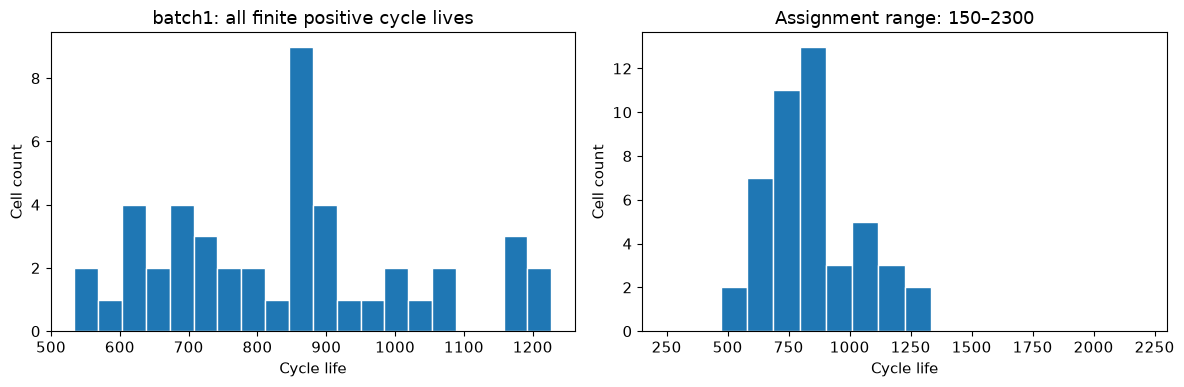

,count
total_cells,46
valid_life_cells,46
long_life_gt_1000,10
short_life_lt_500,0
outside_display_range,0


In [5]:
life = cells["cycle_life"]
valid_life = life[np.isfinite(life) & (life > 0)]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(valid_life, bins=20, edgecolor="white")
axes[0].set_title(f"{BATCH_NAME}: all finite positive cycle lives")
axes[1].hist(valid_life, bins=np.linspace(150, 2300, 21), edgecolor="white")
axes[1].set_title("Assignment range: 150–2300")
axes[1].set_xlim(150, 2300)
for ax in axes:
    ax.set_xlabel("Cycle life")
    ax.set_ylabel("Cell count")
plt.tight_layout()
output_dir = PROJECT_ROOT / "outputs/figures" / BATCH_NAME
output_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(output_dir / "initial_cycle_life_histogram.png", dpi=140)
plt.show()
display(pd.Series({
    "total_cells": len(cells), "valid_life_cells": len(valid_life),
    "long_life_gt_1000": int((valid_life > 1000).sum()),
    "short_life_lt_500": int((valid_life < 500).sum()),
    "outside_display_range": int((~valid_life.between(150, 2300)).sum()),
}).to_frame("count"))

### 관찰 기록

- 사용 조건: 위 `BATCH_NAME`, 원본 summary, 필터 없음.
- 관찰: 실행한 표와 그래프에서 확인한 사실을 기록합니다.
- 가설: 사실과 구분하여 가능한 설명을 기록합니다.
- 추가 질문: 초기 0값의 의미, 수명과 기록 길이의 차이, Batch 간 동일 셀의 연장 이력을 확인합니다.
- 후속 검증 결과: 추가 분석 후 기록합니다.

## 5. 상세 곡선 선택 접근 확인

여기서는 셀 0의 저장 인덱스 1에서 Qdlin만 읽습니다. 이를 실험 cycle 2라고 확정하지 않습니다.
전압·용량 길이 및 전압 정렬을 확인하며, 전체 상세 시계열을 읽지 않습니다.

In [6]:
curve = load_data.load_cycle_fields(path, cell_id=0, cycle_index=1, fields=("Qdlin",))
print({key: value.shape for key, value in curve.items()})
assert len(curve["Vdlin"]) == len(curve["Qdlin"])
print("Finite voltage:", np.isfinite(curve["Vdlin"]).all())
print("Strictly decreasing voltage:", (np.diff(curve["Vdlin"]) < 0).all())
display(pd.DataFrame({"voltage": curve["Vdlin"], "Qdlin": curve["Qdlin"]}).head())

{'Qdlin': (1000,), 'Vdlin': (1000,)}
Finite voltage: True
Strictly decreasing voltage: True


,voltage,Qdlin
0,3.500000,-0.000357
1,3.498498,-0.000319
2,3.496997,-0.000282
3,3.495495,-0.000247
4,3.493994,-0.000214


## 6. 세 Batch 공통 로딩 검증

한 Batch씩 읽고 확인한 후 해제합니다. 아래 숫자는 정제 전 원본 항목 기준입니다.
Batch 비교 EDA와 제외 기준 결정은 다음 단계에서 진행합니다.

In [7]:
batch_checks = []
for name in load_data.BATCH_FILES:
    c, s, q = load_data.load_batch(load_data.batch_path(name, DATA_DIR), name)
    assert len(c) == s["cell_id"].nunique() == len(q)
    assert s["batch"].eq(name).all()
    assert not s.duplicated(["batch", "cell_id", "cycle"]).any()
    batch_checks.append({
        "batch": name, "cells": len(c), "summary_rows": len(s),
        "mean_cycle_life": c["cycle_life"].mean(),
        "invalid_cycle_life_cells": int((~q["cycle_life_finite_positive"]).sum()),
        "nonfinite_summary_values": int(q.filter(regex="_nonfinite$").sum().sum()),
        "QD_zero_values": int(q["QD_zero"].sum()),
        "cycle_length_mismatch_cells": int((~q["cycle_lengths_match_summary"]).sum()),
        "summary_max_exceeds_cycle_life_cells": int((q["cycle_max"].to_numpy() > c["cycle_life"].to_numpy()).sum()),
    })
    del c, s, q
display(pd.DataFrame(batch_checks))

,batch,cells,summary_rows,mean_cycle_life,invalid_cycle_life_cells,nonfinite_summary_values,QD_zero_values,cycle_length_mismatch_cells,summary_max_exceeds_cycle_life_cells
0,batch1,46,38811,844.717391,0,0,46,0,0
1,batch2,47,26904,565.743590,8,0,0,0,39
2,batch3,46,51007,1059.659091,2,0,0,0,0


### 첫 실행에서 확인한 사항 (2026-10-01)

- 세 Batch의 원본 셀 항목 수는 46 / 47 / 46이며 summary 행 수는 38,811 / 26,904 / 51,007입니다.
- summary 수치에는 NaN/무한값이 없지만, `cycle_life`에는 Batch 2에서 8개, Batch 3에서 2개 NaN이 있습니다.
- Batch 1에는 QD=0인 행 46개가 있습니다. 결측·초기화 값인지 아직 확정하지 않았습니다.
- Batch 2의 수명 값이 있는 39개 셀 모두에서 기록 최대 cycle이 `cycle_life`를 초과합니다. 수명 정의와 기록 범위의 관계를 추가 확인해야 합니다.
- 동일 물리 셀의 Batch 간 측정 연장 여부와 상세 cycle 저장 인덱스 대응은 미확인입니다.

위 사항은 자동 제외·치환의 근거로 확정하지 않았습니다. 다음 EDA에서 검토합니다.

## 다음 분석

공통 전처리 기준을 정하고 대표 셀의 열화 곡선을 탐색합니다.
0값·수명과 기록 길이 차이·배치 간 연장 이력을 확인한 뒤, 원본/처리 후 그래프를 비교합니다.
이 노트북은 구조 점검용이며 Feature 선택이나 모델 학습을 수행하지 않습니다.